# Almost-Linear RNNs Tutorial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from tqdm import trange

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

import torch
import torch.nn as nn
from torch.nn.init import uniform_
import torch.nn.functional as F
from torch import optim

from dataset import TimeSeriesDataset
from linear_region_functions import *
import linear_region_functions as lrf
from metrics import state_space_divergence_binning, power_spectrum_error

from matplotlib.colors import Normalize
from collections import Counter
import seaborn as sns
import copy

# Select GPU here when running on a server. Falls back to CPU if CUDA is unavailable.
GPU_ID = 0
if torch.cuda.is_available():
    torch.cuda.set_device(GPU_ID)
    device = torch.device(f"cuda:{GPU_ID}")
else:
    device = torch.device("cpu")
print("Using device:", device)

## AL-RNN Architecture

In [2]:
class AL_RNN(nn.Module):
    def __init__(self, M, P, N, phi_dim=0):
        super(AL_RNN, self).__init__()

        # Initialize model dimensions
        self.M = M
        self.P = P
        self.N = N
        self.phi_dim = phi_dim

        # Initialize model parameters A, W, h, B
        self.A, self.W, self.h = self.initialize_AWh_random()
        self.B = self.init_uniform((self.N, self.M))
        if self.phi_dim > 0:
            self.C = nn.Parameter(torch.zeros(self.M, self.phi_dim))
        else:
            self.register_parameter("C", None)

    def forward(self, z, phi_t=None):
        # Make a copy of the input tensor to retain unactivated values
        z_unactivated = torch.clone(z)

        # Apply ReLU activation on the last P units
        z[:, -self.P :] = F.relu(z[:, -self.P :])

        # Compute the forward pass
        out = self.A * z_unactivated + z @ self.W.t() + self.h
        if self.C is not None:
            if phi_t is None:
                raise ValueError("phi_t must be provided when phi_dim > 0")
            out = out + phi_t @ self.C.t()
        return out

    def initialize_AWh_random(self):
        # Randomly initialize A, W, h
        A = nn.Parameter(
            torch.diagonal(self.normalized_positive_definite(self.M), 0)
        )  # Create diagonal matrix A from normalized positive definite matrix
        W = nn.Parameter(
            torch.randn(self.M, self.M) * 0.01
        )  # Initialize weight matrix W with gaussian random numbers
        h = nn.Parameter(torch.zeros(self.M))  # Initialize bias vector h to zero
        return A, W, h

    def normalized_positive_definite(self, M):
        # Generate a normalized positive definite matrix
        R = np.random.randn(M, M).astype(np.float32)
        K = np.matmul(R.T, R) / M + np.eye(M)  # R'R ./ M + I
        eigenvalues = np.linalg.eigvals(K)
        lambda_max = np.max(np.abs(eigenvalues))
        return torch.tensor(K / lambda_max).float()

    def init_uniform(self, shape):
        # Initialize a tensor with a uniform distribution within range [-1/sqrt(M), 1/sqrt(M)]
        tensor = torch.empty(*shape)
        r = 1 / math.sqrt(shape[0])
        torch.nn.init.uniform_(tensor, -r, r)
        return nn.Parameter(tensor, requires_grad=True)


@torch.no_grad()  # Disables gradient calculation to save memory and computation
def predict_free_sequence(model, x, T, phi=None):
    # Predicts a sequence without updating model parameters
    b, N = x.size()

    Z = torch.empty(
        size=(T, b, model.M), device=x.device
    )  # Initialize output tensor for the predicted sequence
    z = x @ model.B  # Initialize first latent state
    z[:, 0:N] = x

    if model.phi_dim > 0 and phi is None:
        raise ValueError("phi must be provided when model.phi_dim > 0")
    if phi is not None and phi.dim() == 2:
        phi = phi.unsqueeze(1)

    # Predict sequence by passing previous state through the model
    for t in range(0, T):
        phi_t = phi[t] if phi is not None else None
        z = model(z, phi_t)
        Z[t] = z
    return Z.permute(1, 0, 2)

## Training routine

In [3]:
def predict_sequence_using_gtf(model, x, alpha, n_interleave, phi=None):
    # Predicts a sequence using teacher forcing (only for training)
    x_ = x.permute(
        1, 0, 2
    )  # Permute input to shape (sequence_length, batch_size, feature_dim)
    T, b, dx = x_.size()  # T: sequence length, b: batch size, dx: feature dimension
    Z = torch.empty(size=(T, b, model.M), device=x.device)
    if model.phi_dim > 0 and phi is None:
        raise ValueError("phi must be provided when model.phi_dim > 0")
    phi_ = phi.permute(1, 0, 2) if phi is not None else None
    z = x_[0] @ model.B  # Initialize first latent state
    z = teacher_force(z, x_[0], alpha=1)  # Apply teacher forcing to the initial state

    # Generate sequence predictions
    for t in range(0, T):
        # Apply teacher forcing at regular intervals
        if (t % n_interleave == 0) and (t > 0):
            z = teacher_force(z, x_[t], alpha)

        # Update the latent state using the model
        phi_t = phi_[t] if phi_ is not None else None
        z = model(z, phi_t)
        Z[t] = z
    return Z.permute(1, 0, 2)


def teacher_force(z, x, alpha):
    # Teacher force the state z
    z[:, :N] = alpha * x + (1 - alpha) * z[:, :N]
    return z


def train_sh(
    model,
    dataset,
    optimizer,
    scheduler,
    loss_fn,
    num_epochs,
    alpha,
    n_interleave,
    batches_per_epoch=50,
    ssi=25,
    use_best_model=True,
):
    model.train()  # Set model to training mode
    best_model = copy.deepcopy(model)  # Initialize best_model saver
    losses = []
    klx = []
    dh = []

    with trange(num_epochs, desc="Training Progress") as epochs:
        # Loop over batches in each epoch
        for e in epochs:
            epoch_losses = []

            for _ in range(batches_per_epoch):
                optimizer.zero_grad()  # Reset gradients for the optimizer

                x, y, s = (
                    dataset.sample_batch()
                )  # Sample a batch of data (x: inputs, y: targets)
                x = x.to(device)
                y = y.to(device)
                s = s.to(device) if s is not None else None
                z_hat = predict_sequence_using_gtf(
                    model, x, alpha, n_interleave, s
                )  # Predict sequence using teacher forcing
                loss = loss_fn(z_hat[:, :, : model.N], y)  # Calculate loss
                loss.backward()  # Backward pass
                optimizer.step()
                epoch_losses.append(loss.item())

            scheduler.step()  # Adjust learning rate based on the scheduler

            # Compute and store average loss for the epoch
            average_epoch_loss = sum(epoch_losses) / len(epoch_losses)
            epochs.set_postfix(loss=average_epoch_loss)
            losses.append(average_epoch_loss)

            # Save dynamical systems performance metrics Dstsp and DH each #ssi(scalar saving interval) epochs
            if e % ssi == 0:
                with torch.no_grad():
                    s_test = (
                        dataset.S.clone().detach()[0:10000, :].unsqueeze(1).to(device)
                        if dataset.S is not None
                        else None
                    )
                    x0_test = dataset.X.clone().detach()[0:1, :].to(device)
                    z_test = predict_free_sequence(
                        model, x0_test, 10000, s_test
                    )  # Freely generate sequence
                    z_test_obs = z_test[0, :, 0 : model.N].detach().cpu()
                    x_train_cpu = dataset.X.clone().detach().cpu()
                    klx.append(
                        state_space_divergence_binning(
                            z_test_obs, x_train_cpu
                        )
                    )  # Calculate Dstsp
                    dh.append(
                        power_spectrum_error(
                            z_test_obs,
                            x_train_cpu[0:10000, :],
                        )
                    )  # Calculate DH

                    if torch.argmin(torch.tensor(klx)) + 1 == len(
                        torch.tensor(klx)
                    ):  # Check if current model is best according to Dstsp
                        best_model = copy.deepcopy(model)  # Copy the best model

    if use_best_model:  # If true the best model (according to Dstsp) during training is returned, else the one from the last epoch
        model.load_state_dict(best_model.state_dict())

    return [losses, klx, dh]

## Load Data

In [ ]:
# Original Lorenz setup, kept here as reference:
# X_train = np.load("lorenz63_train.npy").astype(np.float32)[500:]
# X_test = np.load("lorenz63_test.npy").astype(np.float32)[500:]

# Plain AL-RNN sanity check on one fixed Halvorsen trajectory, a=1.4 / phi=-1.
# Windows path kept for local runs:
# halvorsen_path = r"C:\Users\koray\OneDrive\Dokumente\Studium\Master\Heidelberg\Master_Thesis\generate_trainingdata\diffrentbutconst_prams\single_halvorsen\just14_noisy\trajectories"
halvorsen_path = "/export/home/klenkeit/training_data/single_halvorsen_constparams/just14_noisy_trajectories"
trajectories = np.load(os.path.join(halvorsen_path, "trajectories.npy")).astype(
    np.float32
)
trajectory_id = 0
X = trajectories[trajectory_id]
split_idx = 80000
X_train = X[:split_idx]
X_test = X[split_idx:]

# Optional external input with shape (T, phi_dim). Keep None for the plain AL-RNN test.
# Example later: Phi_train = np.load("...").astype(np.float32)[500:]
#                Phi_test = np.load("...").astype(np.float32)[500:]
Phi_train = None
Phi_test = None
phi_dim = 0 if Phi_train is None else Phi_train.shape[-1]

T_train, N = X_train.shape
T_test = X_test.shape[0]

## Initialize Model

In [5]:
# number readout units
N = X_train.shape[-1]
# number of units in total
M = 20
# number of piecewise linear units
P = 2

model = AL_RNN(M=M, P=P, N=N, phi_dim=phi_dim).to(device)

## Training hyperparameters

In [6]:
batch_size = 16
sequence_length = 200
# teacher forcing alpha (GTF)
alpha = 1
# teacher forcing interval (readout units are forced every time steps)
n_interleave = 16

loss_fn = nn.MSELoss()
dataset = TimeSeriesDataset(
    X_train,
    external_inputs=Phi_train,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

## Optimization

In [7]:
# optimization
num_epochs = 2000
start_learning_rate = 1e-3
optimizer = torch.optim.RAdam(model.parameters(), lr=start_learning_rate)
# Setup scheduler
end_learning_rate = 1e-5
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=np.exp(np.log(end_learning_rate / start_learning_rate) / num_epochs),
)

## Training

In [8]:
metrics = train_sh(
    model,
    dataset,
    optimizer,
    scheduler,
    loss_fn,
    num_epochs=num_epochs,
    alpha=alpha,
    n_interleave=n_interleave,
    batches_per_epoch=50,
    ssi=20,
)

Training Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

Training Progress:   0%|          | 0/2000 [00:05<?, ?it/s, loss=0.896]c:\Users\koray\OneDrive\Dokumente\Studium\Master\Heidelberg\Master_Thesis\ALRNN-DSR\alrnn_python\metrics.py:31: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:656.)
  return tens(coordinates.t(), indices, size=size_).to_dense()
Training Progress:   5%|▍         | 99/2000 [10:32<3:22:26,  6.39s/it, loss=0.0343]


KeyboardInterrupt: 

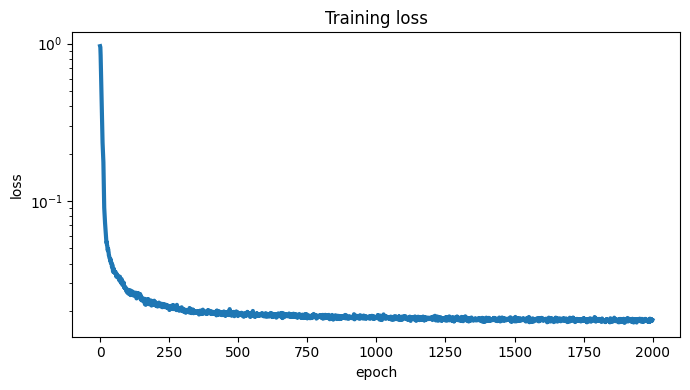

In [ ]:
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams.update({"font.size": 10})
fig = plt.figure()

ax = fig.add_subplot(111)
ax.plot(metrics[0], lw=3)
ax.set_title("Training loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_yscale("log")

plt.tight_layout()
plt.show()

## Saving/Loading

In [ ]:
torch.save(model.state_dict(), "models/halvorsen_just14_m20_p2_plain")

In [ ]:
model = AL_RNN(M=M, P=P, N=N, phi_dim=phi_dim).to(device)
model.load_state_dict(torch.load("models/halvorsen_just14_m20_p2_plain", map_location=device))

<All keys matched successfully>

## Analysis

In [ ]:
X_test_torch = torch.tensor(X_test[:], device=device).unsqueeze(0)

T_gen = 10000  # Sequence length
T_r = 1000  # Transient cutoff length
Phi_test_torch = (
    torch.tensor(Phi_test[: T_gen + T_r], device=device).unsqueeze(1) if Phi_test is not None else None
)
orbit = (
    predict_free_sequence(model, X_test_torch[:, 0, :], T_gen + T_r, Phi_test_torch)
    .detach()
    .cpu()
    .numpy()[0][T_r:, :]
)  # Predict a sequence

Dstsp = state_space_divergence_binning(
    torch.tensor(orbit[:, 0 : model.N]), X_test_torch[0, :, :].detach().cpu()
)
DH = power_spectrum_error(
    torch.tensor(orbit[:, 0 : model.N]), X_test_torch[0, 0:T_gen, :].detach().cpu()
)
print("State space distance (Dstsp): ", Dstsp)
print("Hellinger Distance (DH): ", DH)

State space distance (Dstsp):  3.3486273288726807
Hellinger Distance (DH):  0.06971612


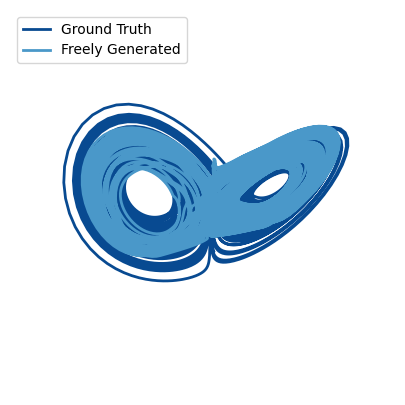

In [ ]:
Blues = plt.cm.Blues
plt.rcParams["lines.linewidth"] = 0.35
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams.update({"font.size": 10})
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
xs = orbit[:, 0]
ys = orbit[:, 1]
zs = orbit[:, 2]

ax.plot(
    X_test[:T_gen, 0],
    X_test[:T_gen, 1],
    X_test[:T_gen, 2],
    color=Blues(0.9),
    label="Ground Truth",
)
ax.plot(xs, ys, zs, color=Blues(0.6), alpha=1.0, label="Freely Generated")

plt.legend(loc="upper left")

plt.axis("off")
plt.show()

In [ ]:
generated_latent = orbit[:, -P:]  # latent sequence in PWL units
generated_observations = orbit[:, :N]  # predicted readout sequence

bits = lrf.convert_to_bits(
    generated_latent
)  # sequence of current active subregion, encoded in bits
regions, unique_regions = lrf.unique_regions_crossed(
    bits, M
)  # Number of linear subregions, used linear subregions encoded as bits
frequencies = lrf.frequency_of_regions(
    bits, unique_regions
)  # How often is each subregion visited

# Compute order of most freqnent visited subregions
frequency_list = np.copy(frequencies)
regions_list = np.copy(unique_regions)
most_frequent_regions = []
for _ in range(len(frequency_list)):
    index = np.argmax(frequency_list)
    most_frequent_regions.append(regions_list[index])
    frequency_list = np.delete(frequency_list, index)
    regions_list = np.delete(regions_list, index, axis=0)

In [ ]:
connectome = lrf.connectome_with_self_connections(
    bits, most_frequent_regions, len(most_frequent_regions)
)
print("Used subregions: ", len(connectome))
print("Timesteps in subregion: ", frequencies)

Used subregions:  4
Timesteps in subregion:  [3771 3883  347 1999]


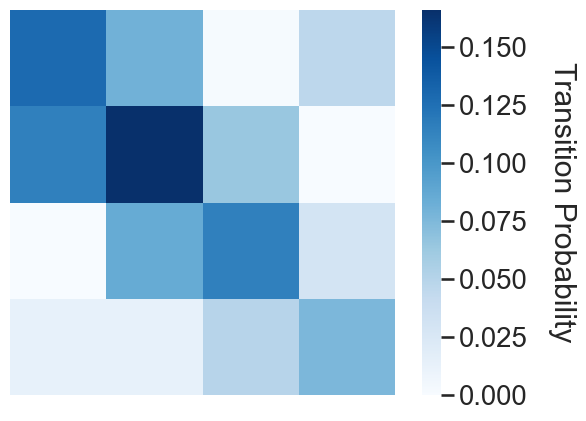

In [ ]:
plt.figure(figsize=(7, 5))
sns.set_context("talk", font_scale=1.2)
sns.set_style("white")

# Define a custom diverging colormap with higher contrast
# cmap = sns.diverging_palette(220, 20, as_cmap=True)
cmap = plt.get_cmap("Blues")

# Plot the heatmap with selected improvements
ax = sns.heatmap(
    data=connectome[:, :],
    annot=False,
    linewidths=0,
    cmap=cmap,
    square=True,
    yticklabels=False,
    xticklabels=False,
    cbar_kws={"label": "Transition Probability"},
)

# Rotate the colorbar label for better visibility
cbar = ax.collections[0].colorbar
cbar.set_label("Transition Probability", rotation=270, labelpad=35)

# Optionally, adjust the limits of the color map to enhance contrast
ax.collections[0].set_clim(0, np.max(connectome) - 0.015)

plt.show()

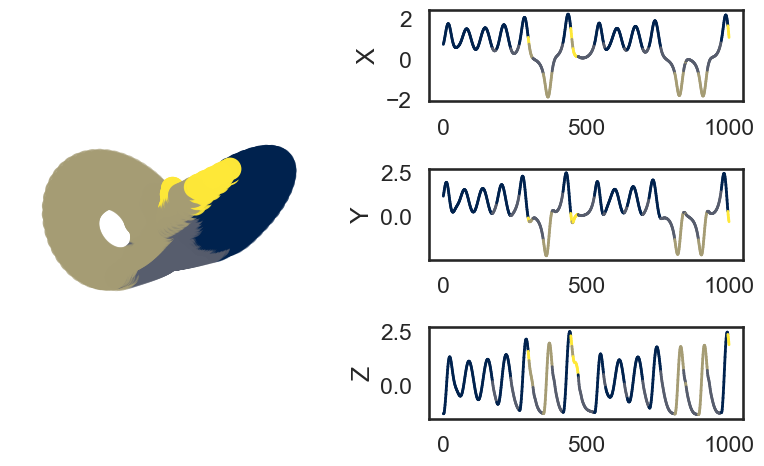

In [ ]:
sns.set_context("talk", font_scale=1.0)
plt.rcParams["lines.linewidth"] = 2.0

observations_plot = generated_observations[:, :3]
bitcode_plot = lrf.convert_to_bits(generated_latent)

# Convert bitcode arrays to strings
bitcodes_str = ["".join(map(str, map(int, b))) for b in bitcode_plot]

# Count the frequency of each bitcode
bitcode_freq = Counter(bitcodes_str)
most_frequent_regions = [item[0] for item in bitcode_freq.most_common()]
frequency_order_map = {code: idx for idx, code in enumerate(most_frequent_regions)}
order = [frequency_order_map[code] for code in bitcodes_str]

# Normalize order indices for color mapping
order_array = np.array(order)
norm = Normalize(vmin=order_array.min(), vmax=order_array.max())
cmap = plt.get_cmap("cividis")
colors = cmap(norm(order_array))

fig = plt.figure(figsize=(8, 5))
# fig.tight_layout()
ax = fig.add_subplot(121, projection="3d")
scatter = ax.scatter(
    observations_plot[:, 0],
    observations_plot[:, 1],
    observations_plot[:, 2],
    c=colors,
    s=220,
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.axis("off")

ax = fig.add_subplot(322)
for i in range(1000):
    ax.plot(
        [i, i + 1],
        [observations_plot[i, 0], observations_plot[i + 1, 0]],
        color=colors[i + 1],
    )
ax.set_ylabel("X")

ax = fig.add_subplot(324)
for i in range(1000):
    ax.plot(
        [i, i + 1],
        [observations_plot[i, 1], observations_plot[i + 1, 1]],
        color=colors[i + 1],
    )
ax.set_ylabel("Y")

ax = fig.add_subplot(326)
for i in range(1000):
    ax.plot(
        [i, i + 1],
        [observations_plot[i, 2], observations_plot[i + 1, 2]],
        color=colors[i + 1],
    )
ax.set_ylabel("Z")

plt.tight_layout()
plt.show()